# Import

In [37]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch


plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")


# - dirs 
from ciim.src.common import mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets, datasets_all, datasets_healthy, v_datasets, datasets_disease, palette_datasets, palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import read_tf_acts, adata_lambda, net_lambda, calculate_tf_activity, compute_trend, linear_association_with_age, retreive_stats, add_minor_data

from ciim.src.tf_activity.plots import  plot_tf_act_validation,  plot_net_nx, plot_trend_tfs

from ciim.src.utils.plots import dotplot

# Identify sig networks

In [3]:
# - identify consensus networks across datasets with at least 3 datasets shared
consensus_nets = {}
for cell_type in cell_types:
    net_store = []
    for dataset in datasets_healthy:
        net = net_lambda(dataset, cell_type)
        net['dataset'] = dataset
        net_store.append(net)
    nets = pd.concat(net_store)

    nets['link'] = nets['source'] + '_' + nets['target']
    degrees = nets.groupby(['link'])['dataset'].size()
    shared_links = degrees[degrees>=3].index
    nets = nets[nets['link'].isin(shared_links)]


    net_mean = nets.groupby(['source', 'target', 'cell_type'])['weight'].mean().reset_index()

    consensus_nets[cell_type] = net_mean

In [4]:
# - extract sig tfs for cell types
stats_all = pd.read_csv('../output/tf_activation/stats_all_bulk.csv')
stats_consistent = stats_all[stats_all['analysis'] == 'validation']
stats_consistent = stats_consistent[stats_consistent['trend'] != 'Inconsistent'][['cell_type', 'tf', 'meta_p_adj', 'trend']].drop_duplicates()
stats_consistent = stats_consistent[stats_consistent['meta_p_adj'] < 0.05]
sig_tfs_dict = stats_consistent.groupby(['cell_type'])['tf'].unique().to_dict()

In [5]:
# - subset stats_target to only those targets that are connected to sig tfs
stats_target_all = pd.read_csv('../output/tf_activation/stats_targets_bulk.csv')
stats_target_store = []
for cell_type, sig_tfs in sig_tfs_dict.items():
    stats_target = stats_target_all[(stats_target_all['cell_type'] == cell_type) & (stats_target_all['dataset'].isin(datasets_healthy))]
    net = consensus_nets[cell_type]
    targets = net[net['source'].isin(sig_tfs)]['target'].unique()
    stats_target = stats_target[stats_target['target'].isin(targets)]
    stats_target_store.append(stats_target)
stats_target_all = pd.concat(stats_target_store)

# - meta analysis to identify consistent targets across datasets
from ciim.src.tf_activity.meta_analysis.helper import wrapper_meta_analysis
stats_all_c = stats_target_all.copy()
stats_all_c.rename(columns={'p_value': 'pvalue', 'target':'gene'}, inplace=True)
meta_analysis_type = 'max'
df_meta_all = wrapper_meta_analysis(stats_all_c, type=meta_analysis_type, min_degree=3, temp_dir='../output/tmp')
df_meta_all.rename(columns={'gene': 'target'}, inplace=True)
stats_target_all = stats_target_all.merge(df_meta_all, on=['target', 'cell_type'], how='left')
stats_target_all = compute_trend(stats_target_all, pval_col= 'meta_p_adj', slope_col='slope', col='target')
stats_target_consistent = stats_target_all[stats_target_all['meta_p_adj'] < 0.05]
stats_target_consistent = stats_target_consistent[stats_target_consistent['trend'] != 'Inconsistent'][['cell_type', 'target', 'meta_p_adj', 'trend']].drop_duplicates()

print(stats_target_consistent.groupby(['cell_type', 'trend']).size().reset_index(name='counts'))
sig_targets_dict = stats_target_consistent.groupby(['cell_type'])['target'].unique().to_dict()

CD4T (484, 4)
CD8T (1122, 4)
NK (82, 4)
  cell_type              trend  counts
0      CD4T  Increase in aging      72
1      CD4T  Decrease in aging       5
2      CD4T       Inconsistent       0
3      CD8T  Increase in aging     558
4      CD8T  Decrease in aging     160
5      CD8T       Inconsistent       0
6        NK  Increase in aging       2
7        NK  Decrease in aging       2
8        NK       Inconsistent       0


In [6]:
# - subset consensus networks to only those targets that are connected to sig tfs
sig_nets = {}
for cell_type, sig_tfs in sig_tfs_dict.items():
    net = consensus_nets[cell_type]
    sig_targets = sig_targets_dict[cell_type]
    net = net[(net['source'].isin(sig_tfs)) & (net['target'].isin(sig_targets))].reset_index(drop=True)

    net = net.merge(stats_consistent, left_on=['cell_type', 'source'], right_on=['cell_type', 'tf'], how='left')
    net = net.merge(stats_target_consistent, left_on=['cell_type', 'target'], right_on=['cell_type', 'target'], how='left', suffixes=('_tf', '_target'))
    sig_nets[cell_type] = net

# In silico prediction

In [7]:
cell_type = 'CD8T'
dataset = 'data1'
adata = adata_lambda(dataset, type='bulk')
adata = adata[~adata.obs['age'].isna()].copy()
adata.obs['age'] = adata.obs['age'].astype(int)
adata = adata[adata.obs['cell_type'] == cell_type].copy()
net = sig_nets[cell_type]

In [8]:
# - bin 5 years and take the mean of the expression values
expr_df = pd.DataFrame(adata.X, index=adata.obs.index, columns=adata.var_names)
expr_df['age'] = adata.obs['age']
expr_df['age_bin'] = (expr_df['age'].astype(int) // 5) * 5
mean_expr_df = expr_df.groupby('age_bin').mean().drop(columns='age')

ValueError: Shape of passed values is (981, 1), indices imply (981, 17001)

# Overall plots

In [74]:
stats_tfs_all = pd.read_csv(f'../output/tf_activation/stats_all_bulk.csv')

In [75]:
stats_tfs_all['negative_log10_p_value'] = -np.log10(stats_tfs_all['p_value'])
multi_index = pd.MultiIndex.from_product([cell_types, datasets_all], names=["cell_type", "dataset"])

pivot_df = stats_tfs_all.pivot(index="tf", columns=["cell_type", "dataset"], values="negative_log10_p_value")
pivot_df = pivot_df.reindex(columns=multi_index).fillna(0)
pivot_df.head() 

ValueError: Index contains duplicate entries, cannot reshape

In [6]:
pivot_df_n = pivot_df.div(pivot_df.max())
pivot_df_n

cell_type    CD4T                                            CD8T  \
dataset     data1 data7_allTPs_jalil    data13   data12     data1   
tf                                                                  
ABL1       0.0000                0.0  0.000000  0.00000  0.000000   
ACAA1      0.0000                0.0  0.000000  0.00719  0.000000   
ADARB1     0.0000                0.0  0.000000  0.00000  0.000000   
ADNP       0.4783                0.0  0.061059  0.00000  0.028726   
ADNP2      0.0000                0.0  0.000000  0.00000  0.000000   
...           ...                ...       ...      ...       ...   
ZSCAN30    0.0000                0.0  0.129722  0.00000  0.000000   
ZSCAN9     0.0000                0.0  0.000000  0.00000  0.000000   
ZSWIM1     0.0000                0.0  0.000000  0.00000  0.000000   
ZXDB       0.0000                0.0  0.067311  0.00000  0.000000   
ZXDC       0.0000                0.0  0.044693  0.00000  0.000000   

cell_type                                               NK                     \
dataset   data7_allTPs_jalil    data13    data12     data1 data7_allTPs_jalil   
tf                                                                              
ABL1                     0.0  0.000000  0.000000  0.000000                0.0   
ACAA1                    0.0  0.000000  0.242029  0.000000                0.0   
ADARB1                   0.0  0.000000  0.000000  0.000000                0.0   
ADNP                     0.0  0.000000  0.000000  0.450746                0.0   
ADNP2                    0.0  0.055594  0.000000  0.000000                0.0   
...                      ...       ...       ...       ...                ...   
ZSCAN30                  0.0  0.000000  0.000000  0.000000                0.0   
ZSCAN9                   0.0  0.480697  0.000000  0.000000                0.0   
ZSWIM1                   0.0  0.585331  0.000000  0.000000                0.0   
ZXDB                     0.0  0.081870  0.000000  0.000000                0.0   
ZXDC                     0.0  0.000000  0.000000  0.000000                0.0   

cell_type                          B                                         \
dataset      data13 data12     data1 data7_allTPs_jalil    data13    data12   
tf                                                                            
ABL1       0.000000    0.0  0.000000                0.0  0.000000  0.000000   
ACAA1      0.000000    0.0  0.000000                0.0  0.000000  0.103795   
ADARB1     0.000000    0.0  0.039441                0.0  0.006901  0.000000   
ADNP       0.000000    0.0  0.000000                0.0  0.000000  0.000000   
ADNP2      0.056901    0.0  0.000000                0.0  0.013228  0.000000   
...             ...    ...       ...                ...       ...       ...   
ZSCAN30    0.000000    0.0  0.000000                0.0  0.000000  0.000000   
ZSCAN9     0.000000    0.0  0.000000                0.0  0.000000  0.000000   
ZSWIM1     0.000000    0.0  0.000000                0.0  0.000000  0.000000   
ZXDB       0.000000    0.0  0.000000                0.0  0.140127  0.000000   
ZXDC       0.000000    0.0  0.000000                0.0  0.000000  0.000000   

cell_type      MONO                                        
dataset       data1 data7_allTPs_jalil    data13   data12  
tf                                                         
ABL1       0.000000           0.355383  0.000000  0.00000  
ACAA1      0.385458           0.287564  0.511996  0.03261  
ADARB1     0.000000           0.000000  0.000000  0.00000  
ADNP       0.000000           0.060802  0.000000  0.00000  
ADNP2      0.000000           0.000000  0.000000  0.00000  
...             ...                ...       ...      ...  
ZSCAN30    0.000000           0.000000  0.000000  0.00000  
ZSCAN9     0.000000           0.000000  0.000000  0.00000  
ZSWIM1     0.000000           0.000000  0.000000  0.00000  
ZXDB       0.000000           0.000000  0.559512  0.00000  
ZXDC       

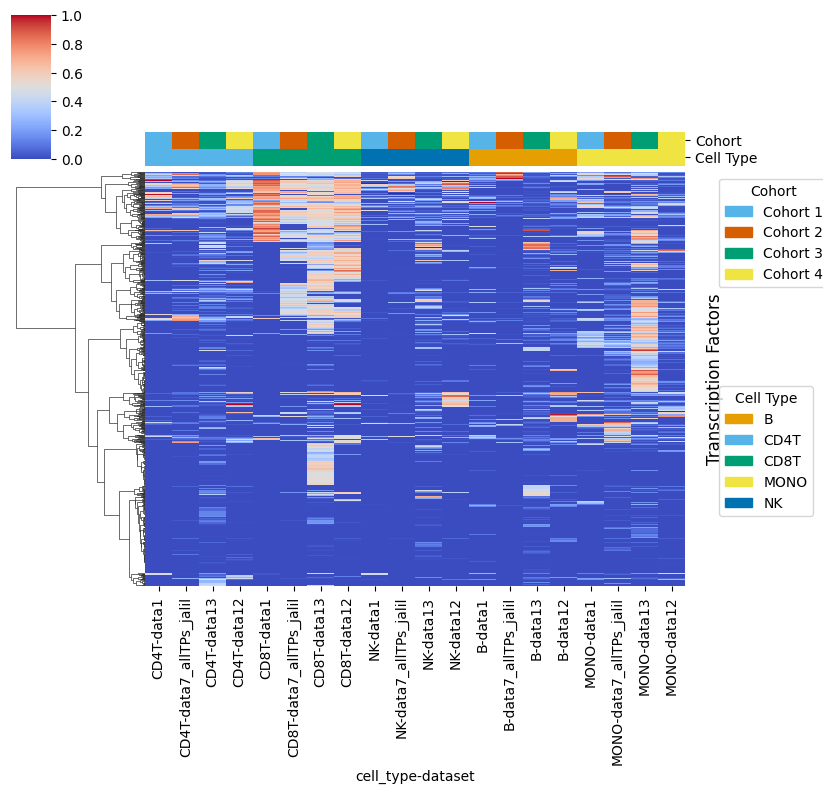

In [7]:
df_plot = pivot_df_n
cohorts = [palette_datasets.get(analysis, "gray") for _, analysis in df_plot.columns]
cell_types = [palette_cell_types.get(ct, "lightgray") for ct, _ in df_plot.columns]

col_colors = pd.DataFrame({
    "Cohort": cohorts,
    "Cell Type": cell_types
}, index=df_plot.columns)

# Clustermap
row_linkage = linkage(df_plot, method='ward')
g = sns.clustermap(
    df_plot,
    row_linkage=row_linkage,
    col_cluster=False,
    row_cluster=True,
    cmap='coolwarm',
    col_colors=col_colors,
    linewidths=0.001,
    linecolor=None,
    figsize=(8, 8),
)

g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_ylabel('Transcription Factors', fontsize=12, labelpad=15)

# Legends
datasets_legend = [Patch(color=color, label=surrogate_names[label]) for label, color in palette_datasets.items()]
celltype_legend = [Patch(color=color, label=label) for label, color in palette_cell_types.items()]

# Create color legends
datasets_legend = [Patch(color=color, label=surrogate_names.get(label, label)) 
                   for label, color in palette_datasets.items()]
celltype_legend = [Patch(color=color, label=label) 
                   for label, color in palette_cell_types.items()]

# Add legends separately with titles
legend1 = g.ax_heatmap.legend(
    handles=datasets_legend,
    title="Cohort",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

legend2 = g.ax_heatmap.legend(
    handles=celltype_legend,
    title="Cell Type",
    bbox_to_anchor=(1.05, 0.5),
    loc='upper left'
)

# Add both legends to the plot
g.ax_heatmap.add_artist(legend1) 
plt.show()

# SLE overal effect

In [77]:
stats_all = pd.read_csv('../output/tf_activation/stats_all.csv')
stats_discovery_consistent = stats_all[stats_all['analysis']=='discovery']
stats_validation = stats_all[stats_all['analysis']=='validation']
stats_sle = stats_all[stats_all['analysis']=='disease']

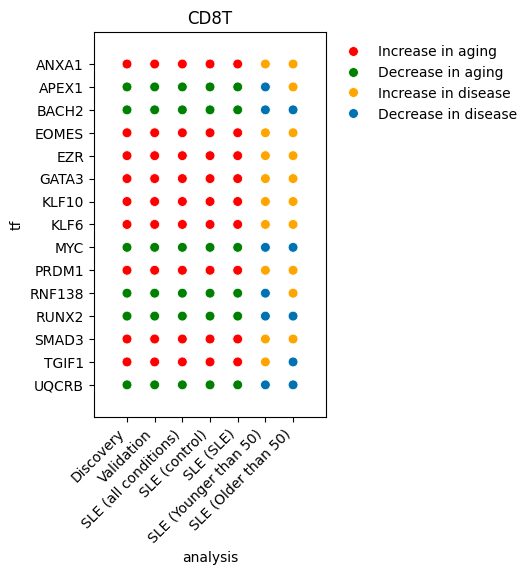

In [92]:
from ciim.src.common import palette_trend, palette_disease_effect
palette_all = {**palette_trend, **palette_disease_effect}

for cell_type in ['CD8T']:
    # - disovery
    discovery_df = stats_discovery_consistent[stats_discovery_consistent['cell_type']==cell_type]
    top_tfs = discovery_df.sort_values('meta_p_adj').head(30)['tf'].unique()
    discovery_df['analysis'] = 'Discovery'

    # - validation
    validation_df = stats_validation[stats_validation['cell_type']==cell_type]
    validation_df['analysis'] = 'Validation'

    # - sle
    disease_df = stats_sle[stats_sle['cell_type']==cell_type]
    stats_a_a = disease_df[(disease_df['condition']=='all') & (disease_df['age_group']=='all')]
    stats_a_a['analysis'] = 'SLE (all conditions)'
    stats_a_a['trend'] = ['Increase in aging' if x > 0 else 'Decrease in aging' for x in stats_a_a['slope']]

    stats_n_a = disease_df[(disease_df['condition']=='normal') & (disease_df['age_group']=='all')]
    stats_n_a['analysis'] = 'SLE (control)'
    stats_n_a['trend'] = ['Increase in aging' if x > 0 else 'Decrease in aging' for x in stats_n_a['slope']]

    stats_d_a = disease_df[(disease_df['condition']=='systemic lupus erythematosus') & (disease_df['age_group']=='all')]
    stats_d_a['analysis'] = 'SLE (SLE)'
    stats_d_a['trend'] = ['Increase in aging' if x > 0 else 'Decrease in aging' for x in stats_d_a['slope']]

    stats_d_y = disease_df[(disease_df['condition']=='systemic lupus erythematosus') & (disease_df['age_group']=='young')]
    stats_d_y['analysis'] = 'SLE (Younger than 50)'
    stats_d_y['trend'] = ['Increase in disease' if x > 0 else 'Decrease in disease' for x in stats_d_y['slope_disease']]

    stats_d_o = disease_df[(disease_df['condition']=='systemic lupus erythematosus') & (disease_df['age_group']=='old')]
    stats_d_o['analysis'] = 'SLE (Older than 50)'
    stats_d_o['trend'] = ['Increase in disease' if x > 0 else 'Decrease in disease' for x in stats_d_o['slope_disease']]


    stats_combined = pd.concat([discovery_df, validation_df, stats_a_a, stats_n_a, stats_d_a, stats_d_y, stats_d_o])
    stats_combined = stats_combined[stats_combined['tf'].isin(top_tfs)]

    fig, ax = plt.subplots(1, 1, figsize=(3, 5))
    sns.scatterplot(data=stats_combined, x='analysis', y='tf', hue='trend', ax=ax, palette=palette_all, s=50)
    ax.margins(x=.2, y=.1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
    plt.title(f'{cell_type}')


In [79]:
# stats_discovery_consistent[stats_discovery_consistent['tf'] == 'SATB1']

# Case TFs

In [9]:
stats_target_all = pd.read_csv('../output/tf_activation/stats_targets_bulk.csv')

In [10]:
def select_top_targets(cell_type, tf, n_top=30):
    net_store = []
    for dataset in datasets_healthy:
        net = net_lambda(dataset, cell_type)
        net = net[net['source']==tf]
        all_targets = net['target'].unique()
        #- select top targets
        stats = stats_target_all[(stats_target_all['target'].isin(all_targets)) & (stats_target_all['dataset']==dataset) & (stats_target_all['cell_type']==cell_type)]
        net = net.merge(stats[['target', 'p_value', 'slope', 'r2']], on='target', how='left')

        net['negative_log10_p_value'] = -np.log10(net['p_value'])
        net['significant'] = net['negative_log10_p_value'] * net['weight'].abs() * net['r2'].abs()
        # net['significant'] = net['slope'].abs()
        top_targets = net.sort_values('significant',  ascending=False).head(20)['target'].unique()
        net['top_target'] = net['target'].isin(top_targets)
        net['reg_sig'] = ['Positive' if x>0 else 'Negative' for x in net['weight']] 
        net['weight_abs'] = abs(net['weight'])
        net['dataset'] = dataset
        net_store.append(net)
    net_tf = pd.concat(net_store)
    top_targets = net_tf[net_tf['top_target']]['target'].unique()
    net_tf = net_tf[net_tf['target'].isin(top_targets)]

    # - select the top n targets
    top_shared_targets = net_tf.groupby(['target'])['dataset'].nunique().sort_values(ascending=False).head(n_top).index
    net_tf = net_tf[net_tf['target'].isin(top_shared_targets)]
    # print(net_tf.pivot(index='target', columns='dataset', values='slope'))
    return net_tf

In [11]:
from ciim.src.tf_activity.plots import plot_targets_across_datasets


tf = 'SATB1'  #'SPI1' #'GATA3' 'SATB1'
net_dict = {}
for cell_type in ['CD8T', 'CD4T', 'NK']:
    net = select_top_targets(cell_type, tf, n_top=20)
    net_dict[cell_type] = net

Text(0.5, 0.98, 'Targets of SATB1')

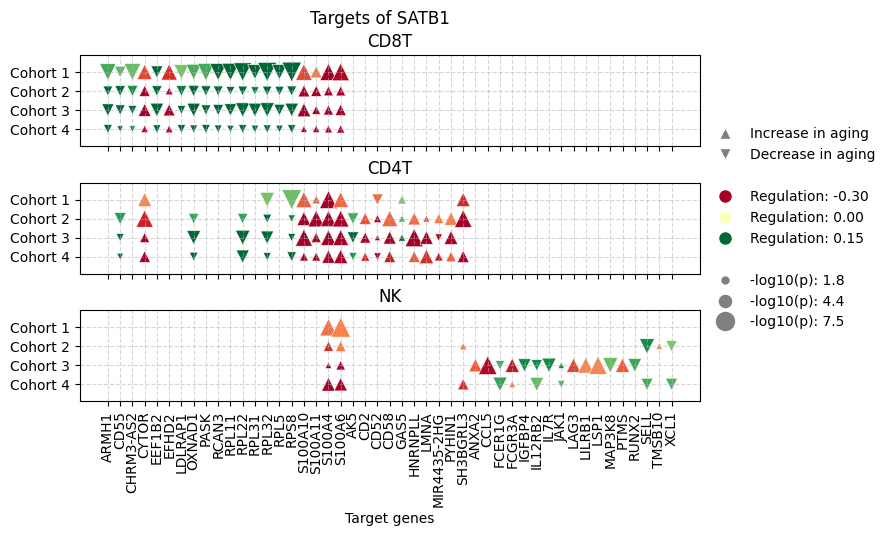

In [15]:

fig, axes = plt.subplots(len(net_dict.keys()), 1, figsize=(8, len(net_dict.keys())*1.5), sharex=True)
for i, (cell_type, net) in enumerate(net_dict.items()):
    ax = axes[i]
    if i == 1:
        show_legend = True
    else:
        show_legend = False
    plot_targets_across_datasets(net.copy(), ax=ax, show_legend=show_legend)
    ax.margins(y=0.3, x=0.05)
    ax.set_title(cell_type)
    ax.set_xlabel('Target genes')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.subplots_adjust(hspace=0.4)
plt.suptitle(f'Targets of {tf}')

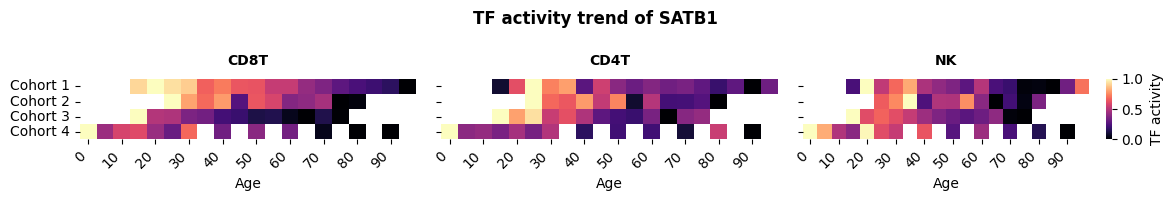

In [13]:
from ciim.src.tf_activity.plots import plot_tfs_trend_across_datasets

cell_types = ['CD8T', 'CD4T', 'NK']
fig, axes = plt.subplots(1, len(cell_types), figsize=(4*len(cell_types), 2), sharey=True)
for i, cell_type in enumerate(cell_types):
    ax = axes[i]
    if i == len(axes)-1:
        show_cbar = True
    else:
        show_cbar = False
    
    plot_tfs_trend_across_datasets(cell_type, tf=tf, datasets=datasets_healthy, ax=ax, show_cbar=show_cbar, tf_acts_dir= '../output/tf_activation/tf_acts/')
    ax.set_ylabel('')
    ax.set_xlabel('Age')
    ax.set_title(cell_type, pad=10, fontsize=10, fontweight='bold')
plt.suptitle(f'TF activity trend of {tf}', fontsize=12, fontweight='bold')
plt.tight_layout()

In [16]:
from ciim.src.tf_activity.plots import plot_net_nx, wrapper_plot_targets
from ciim.src.tf_activity.helper import binarize_expression
if False:
    wrapper_plot_targets(net_dict)

Text(0.5, 1.6, 'TF activity trend of SATB1')

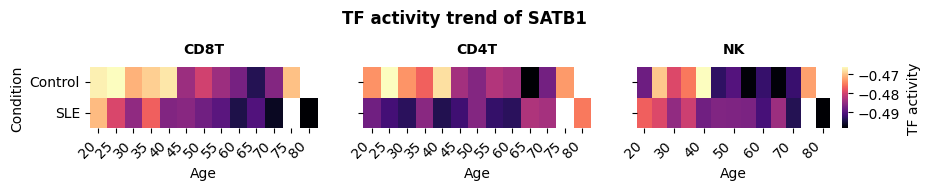

In [17]:
from ciim.src.tf_activity.helper import read_tf_acts
from ciim.src.tf_activity.plots import heatplot_age_trend
dataset = 'SLE'

def format_tf_activation_for_disease_trend_plot(dataset, cell_type):
    tf_acts = read_tf_acts(dataset, cell_type, type='bulk')
    tf_acts = tf_acts[:, tf_acts.var_names==tf]

    expr = tf_acts.to_df()
    expr = expr.merge(tf_acts.obs[['age', 'disease']], left_index=True, right_index=True, how='left')
    expr['disease'] = expr['disease'].astype('category')
    expr['age'] = expr['age'].astype('category')

    # - convert it to index (condition) vs columns (age)
    expr_table = expr.pivot_table(index='disease', columns='age', values=tf)
    expr_table.columns = expr_table.columns.astype(int)

    # - binarize the age
    df = expr_table.copy()
    age_columns = df.columns
    age_bins = {bin_start: [] for bin_start in range(min(age_columns), max(age_columns) + 1, 5)}
    for col in age_columns:
        bin_start = (col // 5) * 5  # Determine the bin start
        age_bins[bin_start].append(col)
    binned_means = {}
    for bin_start, bin_ages in age_bins.items():
        binned_means[bin_start] = df[bin_ages].mean(axis=1)

    binned_df = pd.DataFrame(binned_means)
    return binned_df

fig, axes = plt.subplots(1, 3, figsize=(10, .8), sharey=True)
for i, cell_type in enumerate(['CD8T', 'CD4T', 'NK']):
    ax = axes[i]
    binned_df = format_tf_activation_for_disease_trend_plot(dataset, cell_type)

    binned_df.index = binned_df.index.astype(str)
    
    binned_df.index = binned_df.index.map(surrogate_names)
    if i == len(axes)-1:
        show_cbar = True
    else:   
        show_cbar = False
    
    heatplot_age_trend(binned_df, cmap='magma', cbar_title="TF activity", y_label="Condition", ax=ax, show_cbar=show_cbar, shrink=1)
    if i == 0:
        ax.set_ylabel('Condition')
    else:
        ax.set_ylabel('')
    ax.set_xlabel('Age')
    ax.set_title(cell_type, pad=10, fontsize=10, fontweight='bold')
plt.suptitle(f'TF activity trend of {tf}', fontsize=12, fontweight='bold', y=1.6)

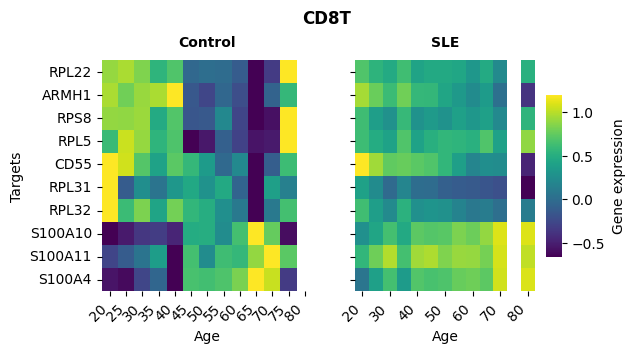

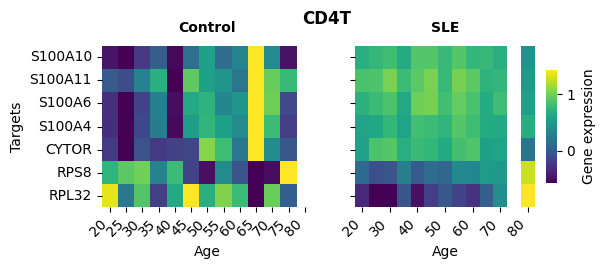

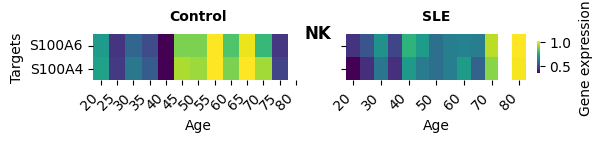

In [104]:
dataset = 'SLE'

# - plot target gene expression trend    
adata_all = adata_lambda(dataset)
for cell_type in ['CD8T', 'CD4T', 'NK']:
    net = net_dict[cell_type]
    # - remove those with conflicting slopes across datasets
    slope_signs = net.pivot(index='target', columns='dataset', values='slope').apply(np.sign)
    mask = slope_signs.sum(axis=1).abs() == len(datasets_healthy)
    consistent_targets = slope_signs[mask].index
    net = net[net['target'].isin(consistent_targets)]
    # - keep those that are at least in three datasets 
    top_targets = net.groupby(['target'])['dataset'].nunique().sort_values(ascending=False)
    top_targets = top_targets[top_targets==len(datasets_healthy)].head(10).index

    
    # - get the expression 
    adata = adata_all[adata_all.obs['cell_type'] == cell_type]
    adata = adata[:, adata.var_names.isin(top_targets)]
    # - binarize and mean
    expr = adata.to_df()
    expr = expr.merge(adata.obs[['age', 'disease']], left_index=True, right_index=True, how='left')
    expr = expr.sort_values('age')
    expr['age_bin'] = (expr['age'].astype(int) // 5) * 5
    expr.drop(columns=['age'], inplace=True)
    mean_expr_all = expr.groupby(['age_bin', 'disease']).mean().reset_index()
    n_groups = len(mean_expr_all['disease'].unique())

    fig, axes = plt.subplots(1, n_groups, figsize=(3*n_groups, .3*len(top_targets)), sharey=False)
    for i, disease in enumerate(mean_expr_all['disease'].unique()):
        ax = axes[i]
        mean_expr = mean_expr_all[mean_expr_all['disease'] == disease].set_index('age_bin').drop(columns=['disease']).T
        if i == 0:
            # Normalize expression
            min_vals = mean_expr.min(axis=1)
            max_vals = mean_expr.max(axis=1)
            show_cbar = False
        else:
            show_cbar = True
    
        mean_expr = (mean_expr.sub(min_vals, axis=0)).div(max_vals - min_vals, axis=0)

        if i == 0:
            from sklearn.cluster import KMeans
            if len(mean_expr) > 2:
                kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
                clusters = kmeans.fit_predict(mean_expr.fillna(0))
                mean_expr['cluster'] = clusters
                mean_expr = mean_expr.sort_values('cluster').drop(columns=['cluster'])
            ordered_targets = mean_expr.index
        else:
            mean_expr = mean_expr.loc[ordered_targets]
        heatplot_age_trend(mean_expr, cmap='viridis', cbar_title="Gene expression", y_label="Targets", ax=ax, show_cbar=show_cbar)
        if i != 0:
            ax.set_ylabel('')
            ax.set_yticklabels([])
        ax.set_xlabel('Age')
        ax.set_title(surrogate_names[disease], pad=10, fontsize=10, fontweight='bold')

    plt.suptitle(cell_type, fontsize=12, fontweight='bold', y=1.05)
# plt.tight_layout()

In [23]:
# read_tf_acts(dataset, cell_type, type='bulk_minor').obs

,sum_by,dataset,donor_id,orig.ident,age_donor,sex,cell_type,batch_group,race,Major_CT,Sub_CT,disease,age,age_group,cell_count
sample,,,,,,,,,,,,,,,
1046,_MAIT_1004_39.0,SLE,1004,SLE,39.0_1004,F,CD8T,batch_1,European,CD8T,MAIT,systemic lupus erythematosus,39.0,35_44,12
1047,_MAIT_1014_40.0,SLE,1014,SLE,40.0_1014,F,CD8T,batch_2,European,CD8T,MAIT,systemic lupus erythematosus,40.0,35_44,83
1048,_MAIT_1015_54.0,SLE,1015,SLE,54.0_1015,F,CD8T,batch_1,European,CD8T,MAIT,systemic lupus erythematosus,54.0,45_54,39
1049,_MAIT_1019_64.0,SLE,1019,SLE,64.0_1019,F,CD8T,batch_2,European,CD8T,MAIT,systemic lupus erythematosus,64.0,55_64,72
1052,_MAIT_1039_42.0,SLE,1039,SLE,42.0_1039,F,CD8T,batch_1,European,CD8T,MAIT,systemic lupus erythematosus,42.0,35_44,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4138,_Tem_Trm_CD8_IGTB645_31.0,SLE,IGTB645,SLE,31.0_IGTB645,F,CD8T,batch_2,European,CD8T,Tem_Trm_CD8,normal,31.0,34-,97
4139,_Tem_Trm_CD8_IGTB670_33.0,SLE,IGTB670,SLE,33.0_IGTB670,F,CD8T,batch_2,European,CD8T,Tem_Trm_CD8,normal,33.0,34-,93
4140,_Tem_Trm_CD8_IGTB826_34.0,SLE,IGTB826,SLE,34.0_IGTB826,F,CD8T,batch_1,European,CD8T,Tem_Trm_CD8,normal,34.0,34-,247


## Sub types

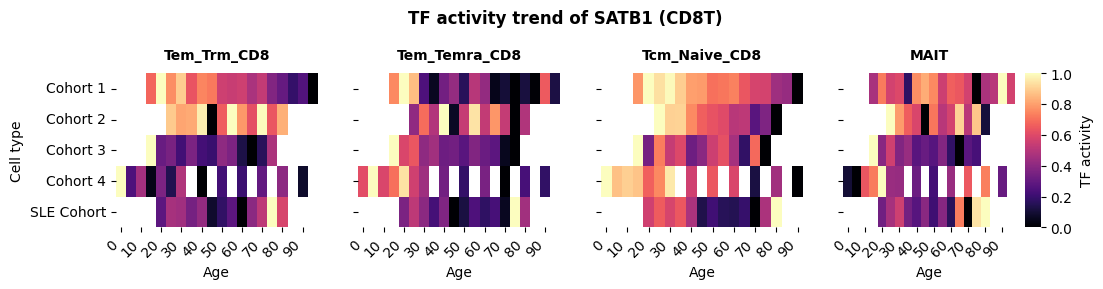

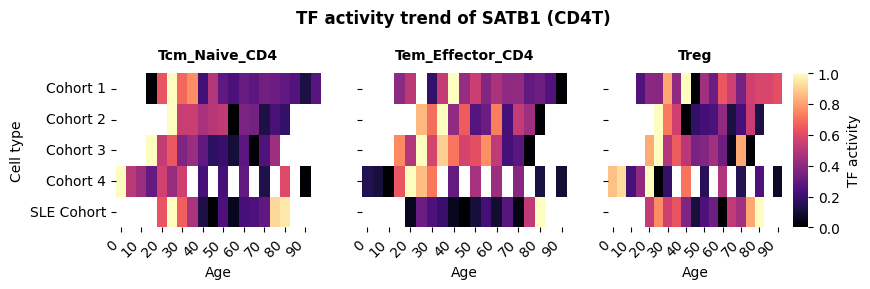

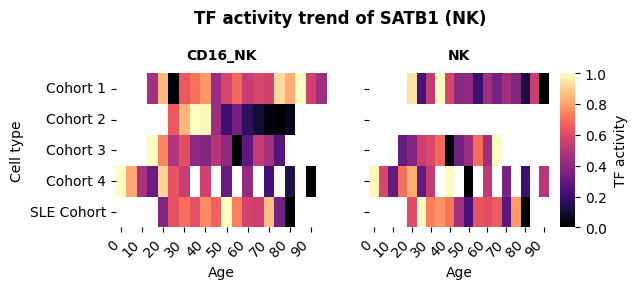

In [48]:
from ciim.src.tf_activity.helper import read_tf_acts
from ciim.src.tf_activity.plots import heatplot_age_trend

def format_tf_activation_for_minor_plot(tf, subtype, datasets):
    cell_type = mapping_minor_2_major[subtype]
    tf_acts_store = []
    for dataset in datasets:
        tf_acts = read_tf_acts(dataset, cell_type, type='bulk_minor')
        tf_acts = tf_acts[tf_acts.obs['Sub_CT'] == subtype]
        tf_acts = tf_acts[:, tf_acts.var_names==tf]
        tf_acts.obs['dataset'] = dataset
        tf_acts_store.append(tf_acts)
    tf_acts = ad.concat(tf_acts_store)
    expr = tf_acts.to_df()
    expr = expr.merge(tf_acts.obs[['age', 'dataset']], left_index=True, right_index=True, how='left')

    expr['dataset'] = expr['dataset'].astype('category')
    expr['age'] = expr['age'].astype('category')

    # - convert it to index (condition) vs columns (age)
    expr_table = expr.pivot_table(index='dataset', columns='age', values=tf)
    expr_table.columns = expr_table.columns.astype(int)
    # - binarize the age
    df = expr_table.copy()
    age_columns = df.columns
    age_bins = {}
    for col in age_columns:
        bin_start = (col // 5) * 5  # Determine the bin start
        if bin_start not in age_bins:
            age_bins[bin_start] = []  # Initialize the list if the bin is not yet in the dictionary
        age_bins[bin_start].append(col)
    binned_means = {}
    for bin_start, bin_ages in age_bins.items():
        binned_means[bin_start] = df[bin_ages].mean(axis=1)

    expr_mean = pd.DataFrame(binned_means)
    min_vals = expr_mean.min(axis=1)
    max_vals = expr_mean.max(axis=1)
    expr_mean = (expr_mean.sub(min_vals, axis=0)).div(max_vals - min_vals, axis=0)
    return expr_mean

#     # - binarize 
#     if True: 
#         expr = adata.to_df()
#         expr = expr.merge(adata.obs[['age']], left_index=True, right_index=True, how='left').set_index('age')
#         # expr = expr[expr.index>10]
#         expr.sort_index(inplace=True)
#         expr['age_bin'] = (expr.index.astype(int) // 5) * 5
#         expr_mean = expr.groupby('age_bin').mean().T
#     # Normalize expression
#     min_vals = expr_mean.min(axis=1)
#     max_vals = expr_mean.max(axis=1)
#     expr_mean = (expr_mean.sub(min_vals, axis=0)).div(max_vals - min_vals, axis=0)
#     return expr_mean

for j, cell_type in enumerate(['CD8T', 'CD4T', 'NK']):
    subtypes = mapping_major_2_minor[cell_type]
    fig, axes = plt.subplots(1, len(subtypes), figsize=(3*len(subtypes), 2), sharey=True)

    for i, subtype in enumerate(subtypes):
        ax = axes[i]
        binned_df = format_tf_activation_for_minor_plot(tf, subtype=subtype, datasets=datasets_all)

        binned_df.index = binned_df.index.astype(str)
        binned_df = binned_df.reindex(datasets_all)
        binned_df.index = binned_df.index.map(lambda name: surrogate_names.get(name, name))

        if i == len(axes)-1:
            show_cbar = True
        else:   
            show_cbar = False
        
        heatplot_age_trend(binned_df, cmap='magma', cbar_title="TF activity", y_label="Condition", ax=ax, show_cbar=show_cbar, shrink=1)
        if i == 0:
            ax.set_ylabel('Cell type')
        else:
            ax.set_ylabel('')
        ax.set_xlabel('Age')
        ax.set_title(subtype, pad=10, fontsize=10, fontweight='bold')
    plt.suptitle(f'TF activity trend of {tf} ({cell_type})', fontsize=12, fontweight='bold', y=1.2)